# Prediksi Gaji Pekerjaan Menggunakan Machine Learning

Notebook ini digunakan untuk menganalisis dan memprediksi gaji pekerjaan berdasarkan fitur seperti pengalaman, pendidikan, lokasi, dll.

## Import Library yang Diperlukan

Kita akan mengimport library Python yang diperlukan untuk analisis data dan machine learning.

In [1]:
# Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor 
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Mengatur style plot
sns.set_theme(style="darkgrid")
sns.set_palette('husl')

## Memuat Dataset

Memuat dataset dari folder data/raw/ dan melihat beberapa baris pertama.

In [2]:
# Memuat dataset
df = pd.read_csv('../data/raw/job_salary_prediction_dataset.csv')

print("Dataset berhasil dimuat!")
print(f"Jumlah baris: {len(df)}")
print(f"Jumlah kolom: {len(df.columns)}")
print("\n5 baris pertama:")
df.head()

Dataset berhasil dimuat!
Jumlah baris: 250000
Jumlah kolom: 10

5 baris pertama:


,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


## Eksplorasi Data

Melihat informasi dataset, statistik deskriptif, dan visualisasi distribusi gaji.

In [3]:
# Informasi dataset
print("Informasi dataset:")
print(df.info())

print("\nStatistik deskriptif:")
df.describe()

Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB
None

Statistik deskriptif:


,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


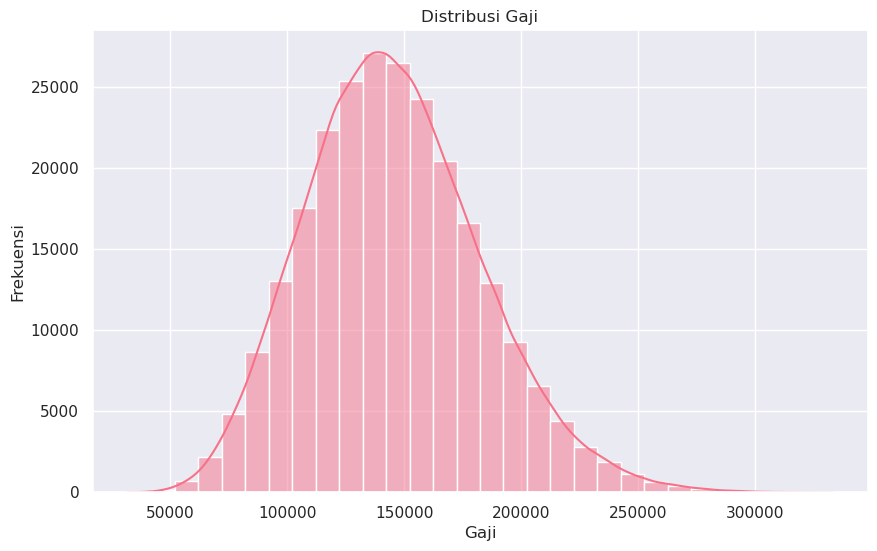

In [4]:
# Visualisasi distribusi gaji
plt.figure(figsize=(10, 6))
sns.histplot(df['salary'], bins=30, kde=True)
plt.title('Distribusi Gaji')
plt.xlabel('Gaji')
plt.ylabel('Frekuensi')
plt.show()

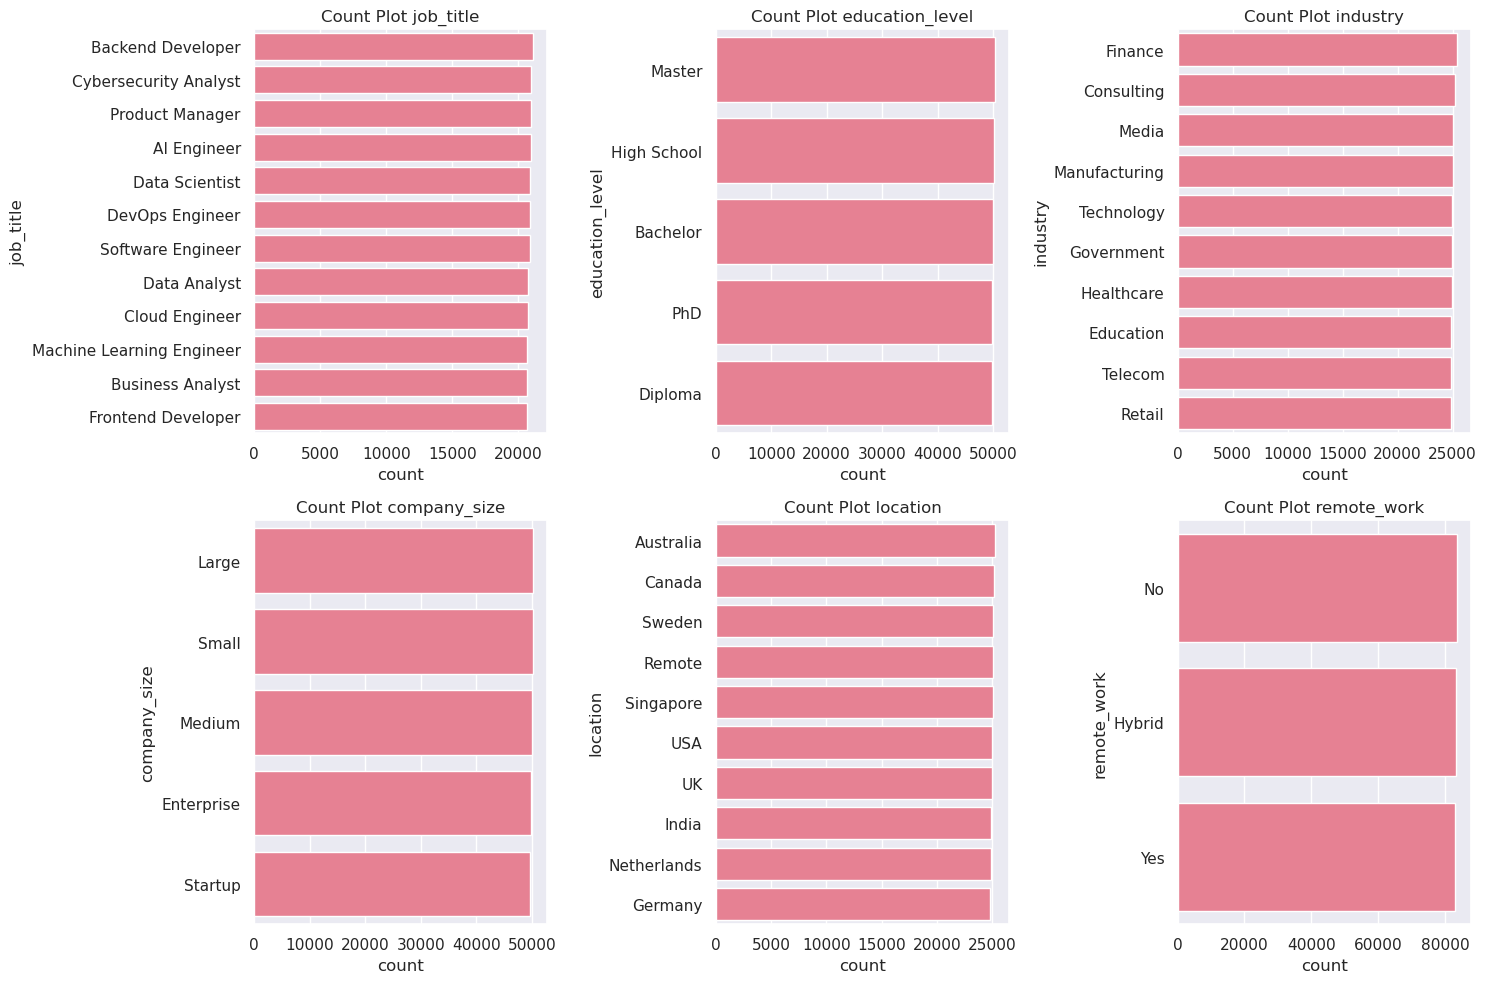

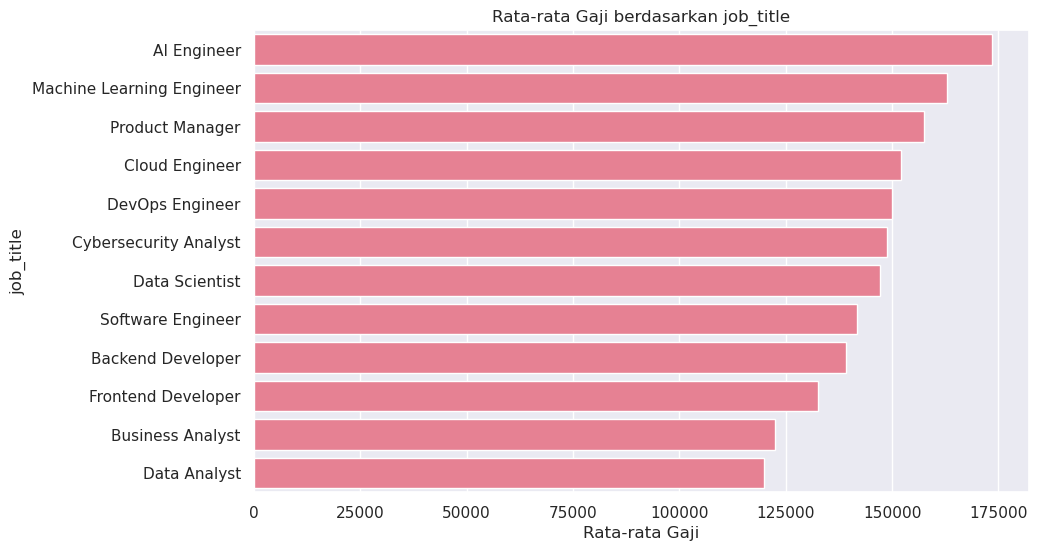

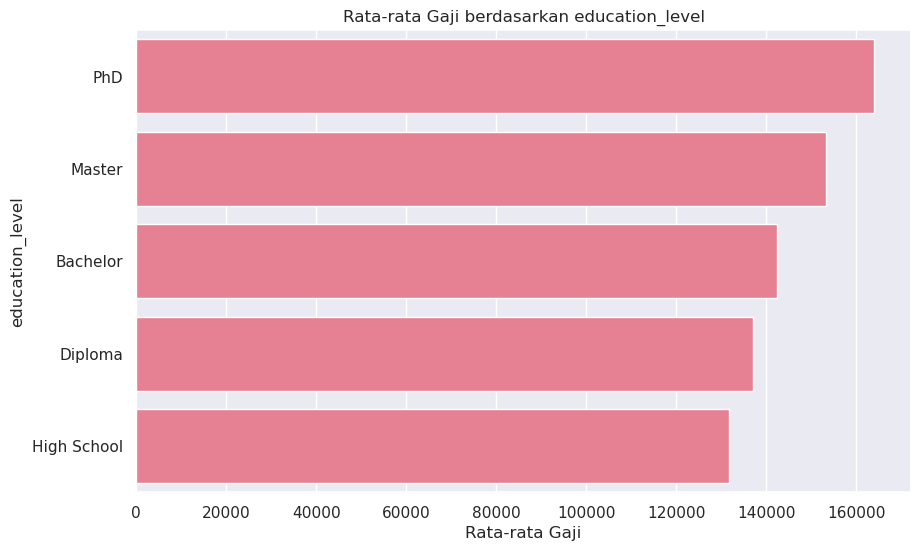

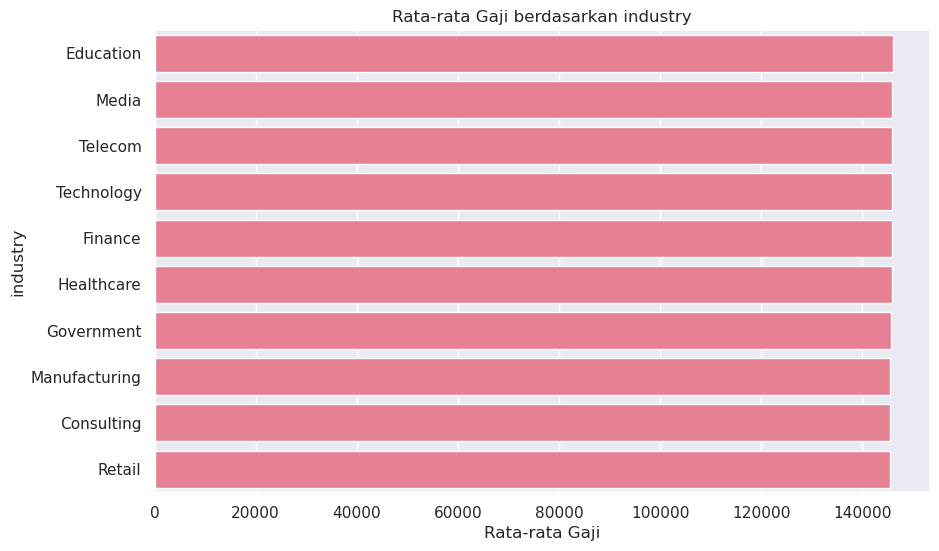

In [5]:
# Count plot untuk fitur kategorikal
categorical_features = df.select_dtypes(include=['object']).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(categorical_features[:6]):  # Tampilkan maksimal 6 fitur
    plt.subplot(2, 3, i+1)
    if len(df[col].unique()) < 20:  # Hanya tampilkan jika kategori tidak terlalu banyak
        sns.countplot(y=df[col], order=df[col].value_counts().index)
        plt.title(f'Count Plot {col}')
    else:
        print(f"Fitur {col} memiliki terlalu banyak kategori unik ({len(df[col].unique())}), tidak ditampilkan.")
plt.tight_layout()
plt.show()

# Rata-rata gaji per kategori
for col in categorical_features[:3]:  # Analisis 3 fitur kategorikal pertama
    if len(df[col].unique()) < 20:
        plt.figure(figsize=(10, 6))
        avg_salary = df.groupby(col)['salary'].mean().sort_values(ascending=False)
        sns.barplot(x=avg_salary.values, y=avg_salary.index)
        plt.title(f'Rata-rata Gaji berdasarkan {col}')
        plt.xlabel('Rata-rata Gaji')
        plt.show()

## Analisis Fitur Kategorikal

Melihat distribusi fitur kategorikal.

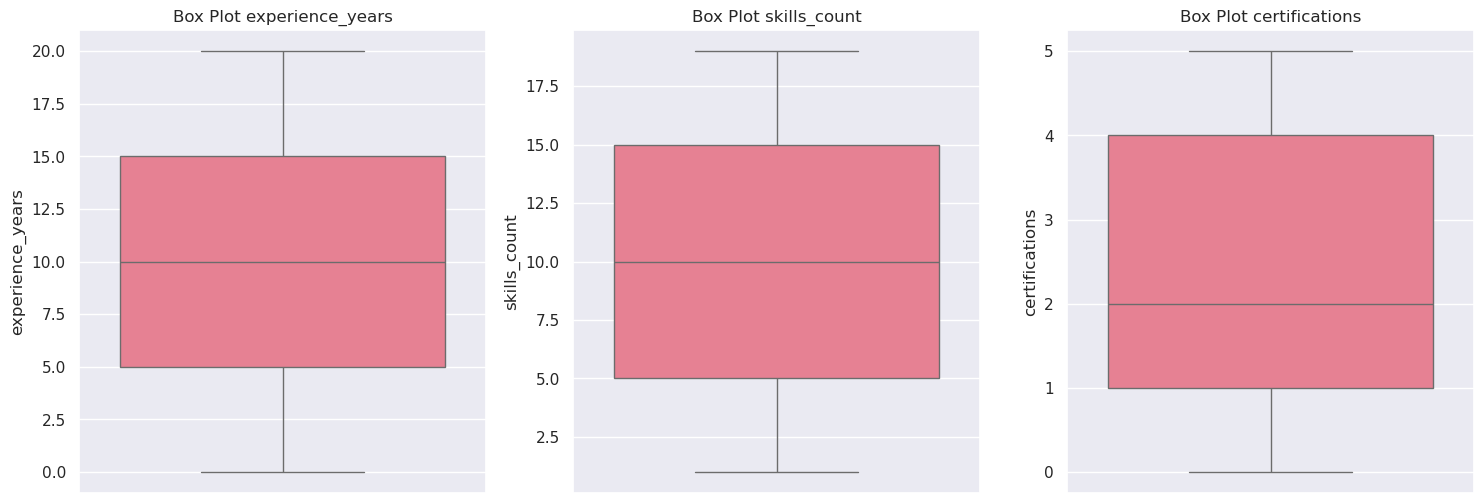

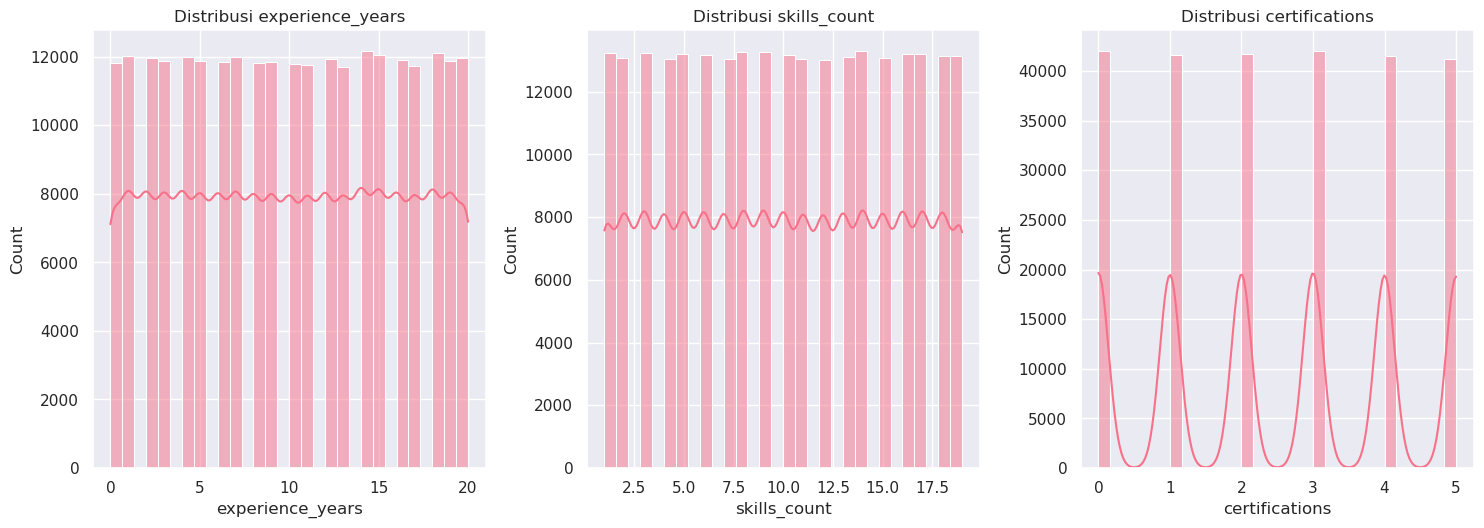

In [6]:
# Box plot untuk fitur numerik
numerical_features = df.select_dtypes(include=[np.number]).columns.drop('salary', errors='ignore')

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_features[:6]):  # Tampilkan maksimal 6 fitur
    plt.subplot(2, 3, i+1)
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot {col}')
plt.tight_layout()
plt.show()

# Distribusi fitur numerik
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_features[:6]):
    plt.subplot(2, 3, i+1)
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f'Distribusi {col}')
plt.tight_layout()
plt.show()

## Analisis Outlier dan Distribusi Fitur Numerik

Melihat box plot untuk mendeteksi outlier pada fitur numerik.

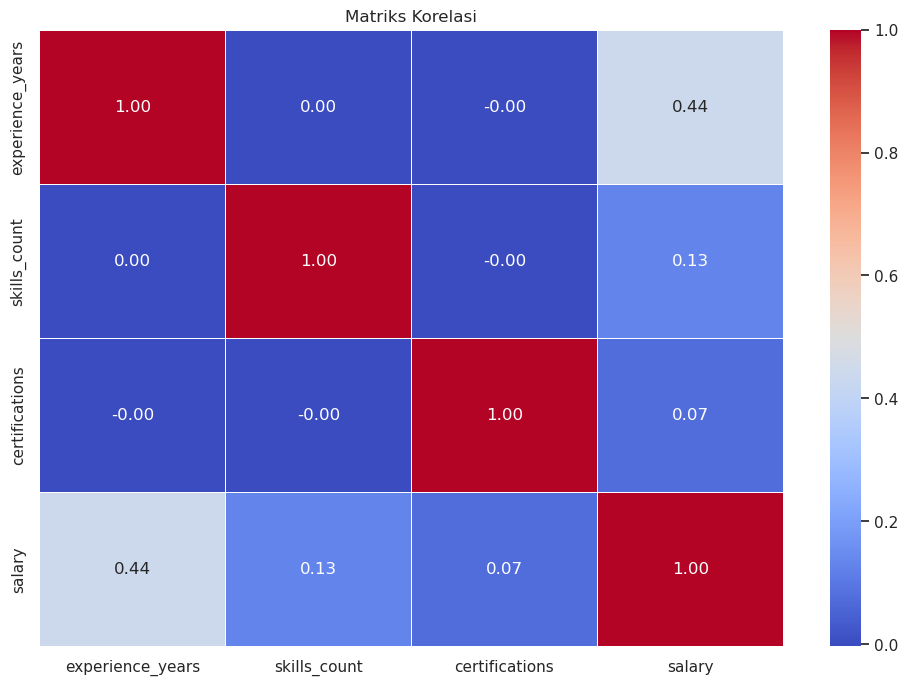

Korelasi fitur dengan gaji:
salary              1.000000
experience_years    0.437627
skills_count        0.127300
certifications      0.073819
Name: salary, dtype: float64


In [7]:
# Matriks korelasi
numerical_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriks Korelasi')
plt.show()

# Korelasi dengan gaji
print("Korelasi fitur dengan gaji:")
print(corr_matrix['salary'].sort_values(ascending=False))

## Analisis Korelasi

Melihat korelasi antara fitur numerik dan target gaji.

In [8]:
# Visualisasi kombinasi: Job Title dan Pendidikan
if 'job_title' in df.columns and 'education' in df.columns:
    plt.figure(figsize=(14, 6))
    sns.boxplot(data=df, x='job_title', y='salary', hue='education')
    plt.title('Distribusi Gaji berdasarkan Job Title dan Tingkat Pendidikan')
    plt.xlabel('Job Title')
    plt.ylabel('Gaji')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Visualisasi kombinasi: Job Title dan Status Remote
if 'job_title' in df.columns and 'remote_status' in df.columns:
    plt.figure(figsize=(14, 6))
    sns.boxplot(data=df, x='job_title', y='salary', hue='remote_status')
    plt.title('Distribusi Gaji berdasarkan Job Title dan Status Remote')
    plt.xlabel('Job Title')
    plt.ylabel('Gaji')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
elif 'job_title' in df.columns and 'remote' in df.columns:
    plt.figure(figsize=(14, 6))
    sns.boxplot(data=df, x='job_title', y='salary', hue='remote')
    plt.title('Distribusi Gaji berdasarkan Job Title dan Status Remote')
    plt.xlabel('Job Title')
    plt.ylabel('Gaji')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

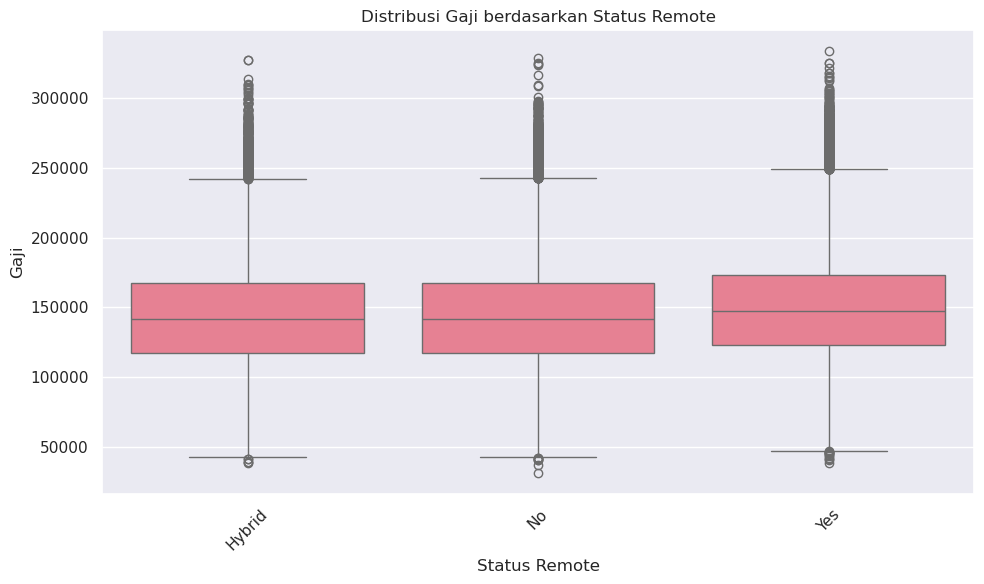

Statistik Gaji berdasarkan Status Remote:
             count           mean    median           std    min     max
remote_work                                                             
Hybrid       83476  143969.899839  141672.0  37071.239937  38779  327217
No           83621  143932.300941  141630.0  37243.626648  31867  328616
Yes          82903  149279.589822  147153.0  37656.806813  39141  333046


In [9]:
# Membuat visualisasi untuk status remote
if 'remote_work' in df.columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x='remote_work', y='salary')
    plt.title('Distribusi Gaji berdasarkan Status Remote')
    plt.xlabel('Status Remote')
    plt.ylabel('Gaji')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    # Statistik gaji per status remote
    print("Statistik Gaji berdasarkan Status Remote:")
    print(df.groupby('remote_work')['salary'].agg(['count', 'mean', 'median', 'std', 'min', 'max']))
elif 'remote' in df.columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x='remote', y='salary')
    plt.title('Distribusi Gaji berdasarkan Status Remote')
    plt.xlabel('Status Remote')
    plt.ylabel('Gaji')
    plt.tight_layout()
    plt.show()
    
    # Statistik gaji per status remote
    print("Statistik Gaji berdasarkan Status Remote:")
    print(df.groupby('remote')['salary'].agg(['count', 'mean', 'median', 'std', 'min', 'max']))
else:
    print("Kolom 'remote_status' atau 'remote' tidak ditemukan. Kolom yang tersedia:", df.columns.tolist())

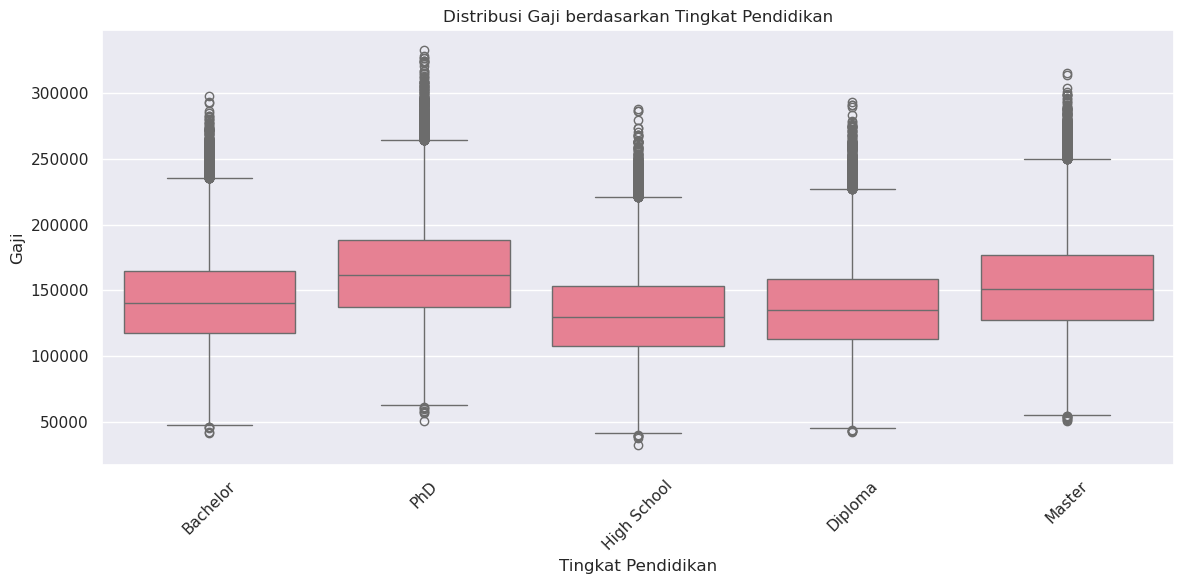

Statistik Gaji berdasarkan Tingkat Pendidikan:
                 count           mean    median           std    min     max
education_level                                                             
Bachelor         49950  142410.531291  140631.5  35105.903931  41276  298070
Diploma          49776  137158.574976  135283.0  34275.205234  41812  293306
High School      50065  131715.336243  129663.0  33601.793888  31867  287961
Master           50352  153305.307833  151396.5  36529.815853  50201  315928
PhD              49857  163976.005295  162005.0  38149.434745  50823  333046


In [10]:
# Membuat visualisasi untuk tingkat pendidikan
if 'education_level' in df.columns:
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df, x='education_level', y='salary')
    plt.title('Distribusi Gaji berdasarkan Tingkat Pendidikan')
    plt.xlabel('Tingkat Pendidikan')
    plt.ylabel('Gaji')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    # Statistik gaji per tingkat pendidikan
    print("Statistik Gaji berdasarkan Tingkat Pendidikan:")
    print(df.groupby('education_level')['salary'].agg(['count', 'mean', 'median', 'std', 'min', 'max']))
else:
    print("Kolom 'education_level' tidak ditemukan. Kolom yang tersedia:", df.columns.tolist())

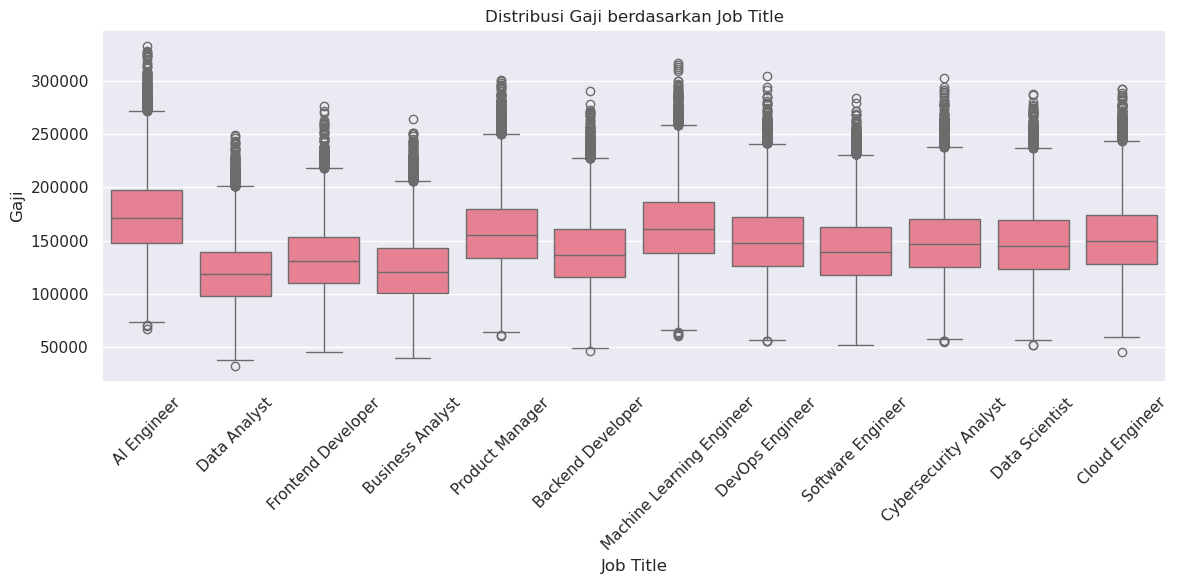

Statistik Gaji berdasarkan Job Title:
                           count           mean    median           std  \
job_title                                                                 
AI Engineer                20945  173498.480640  171674.0  38093.174492   
Backend Developer          21125  139202.768663  136678.0  33198.872580   
Business Analyst           20648  122551.231354  120562.0  31346.360124   
Cloud Engineer             20686  152102.535290  150005.0  35120.102332   
Cybersecurity Analyst      20959  148697.695548  146737.0  34525.312743   
Data Analyst               20722  119891.696603  118079.5  30734.841541   
Data Scientist             20890  147258.214409  145231.5  34227.020507   
DevOps Engineer            20889  149959.266791  148021.0  34455.584420   
Frontend Developer         20633  132653.842485  130619.0  32358.068413   
Machine Learning Engineer  20677  163022.504570  160933.0  36890.759788   
Product Manager            20950  157594.932029  155655.5  357

In [11]:
# Membuat visualisasi untuk job title
if 'job_title' in df.columns:
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df, x='job_title', y='salary')
    plt.title('Distribusi Gaji berdasarkan Job Title')
    plt.xlabel('Job Title')
    plt.ylabel('Gaji')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    # Statistik gaji per job title
    print("Statistik Gaji berdasarkan Job Title:")
    print(df.groupby('job_title')['salary'].agg(['count', 'mean', 'median', 'std', 'min', 'max']))
else:
    print("Kolom 'job_title' tidak ditemukan. Kolom yang tersedia:", df.columns.tolist())

In [12]:
# Cek kolom yang tersedia
print("Kolom dalam dataset:")
print(df.columns.tolist())
print("\nTipe data:")
print(df.dtypes)
print("\nSampel data:")
df.head()

Kolom dalam dataset:
['job_title', 'experience_years', 'education_level', 'skills_count', 'industry', 'company_size', 'location', 'remote_work', 'certifications', 'salary']

Tipe data:
job_title           object
experience_years     int64
education_level     object
skills_count         int64
industry            object
company_size        object
location            object
remote_work         object
certifications       int64
salary               int64
dtype: object

Sampel data:


,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


## Distribusi Gaji berdasarkan Kategori

Analisis distribusi gaji berdasarkan posisi pekerjaan, tingkat pendidikan, dan status remote.

## Preprocessing Data

Membersihkan data, menangani missing values, dan mengencode fitur kategorikal.

In [13]:
# Mengecek missing values
print("Missing values per kolom:")
print(df.isnull().sum())

# Mengisi missing values atau menghapus baris dengan missing values
# (sesuaikan dengan dataset Anda)
df = df.dropna()  # Contoh: menghapus baris dengan missing values

print(f"\nJumlah baris setelah cleaning: {len(df)}")

Missing values per kolom:
job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

Jumlah baris setelah cleaning: 250000


In [14]:
# Encode fitur kategorikal
encoders = {}
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le

print("Fitur kategorikal telah di-encode.")
df.head()


Fitur kategorikal telah di-encode.


,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,0,10,0,2,4,2,3,0,2,109413
1,5,5,0,17,9,3,0,1,0,93764
2,8,18,4,4,6,2,6,1,1,148123
3,2,19,4,13,7,2,1,2,0,189123
4,10,15,0,7,5,1,7,2,0,165069


## Penanganan Outlier dengan Log Transformasi

Menggunakan transformasi log pada target gaji untuk mereduksi pengaruh outlier dan mendapatkan distribusi yang lebih stabil.

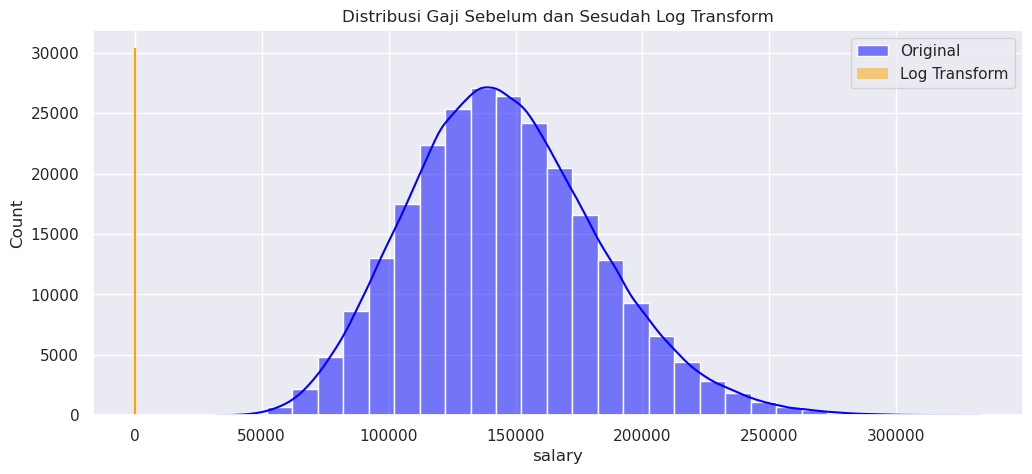

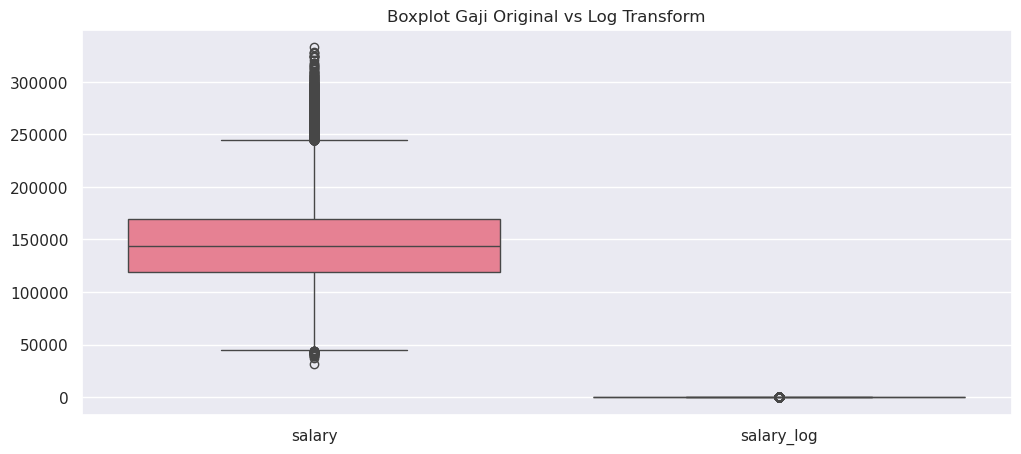

Rata-rata gaji asli: 145718.080524
Rata-rata gaji log: 11.855355484533744
Median gaji asli: 143453.0
Median gaji log: 11.873769705300989


In [15]:
# Log transformasi untuk target gaji
if (df['salary'] <= 0).any():
    raise ValueError('Salary harus positif untuk log transformasi.')

df['salary_log'] = np.log1p(df['salary'])

plt.figure(figsize=(12, 5))
sns.histplot(df['salary'], bins=30, kde=True, color='blue', label='Original', alpha=0.5)
sns.histplot(df['salary_log'], bins=30, kde=True, color='orange', label='Log Transform', alpha=0.5)
plt.title('Distribusi Gaji Sebelum dan Sesudah Log Transform')
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
sns.boxplot(data=df[['salary', 'salary_log']])
plt.title('Boxplot Gaji Original vs Log Transform')
plt.show()

print('Rata-rata gaji asli:', df['salary'].mean())
print('Rata-rata gaji log:', df['salary_log'].mean())
print('Median gaji asli:', df['salary'].median())
print('Median gaji log:', df['salary_log'].median())

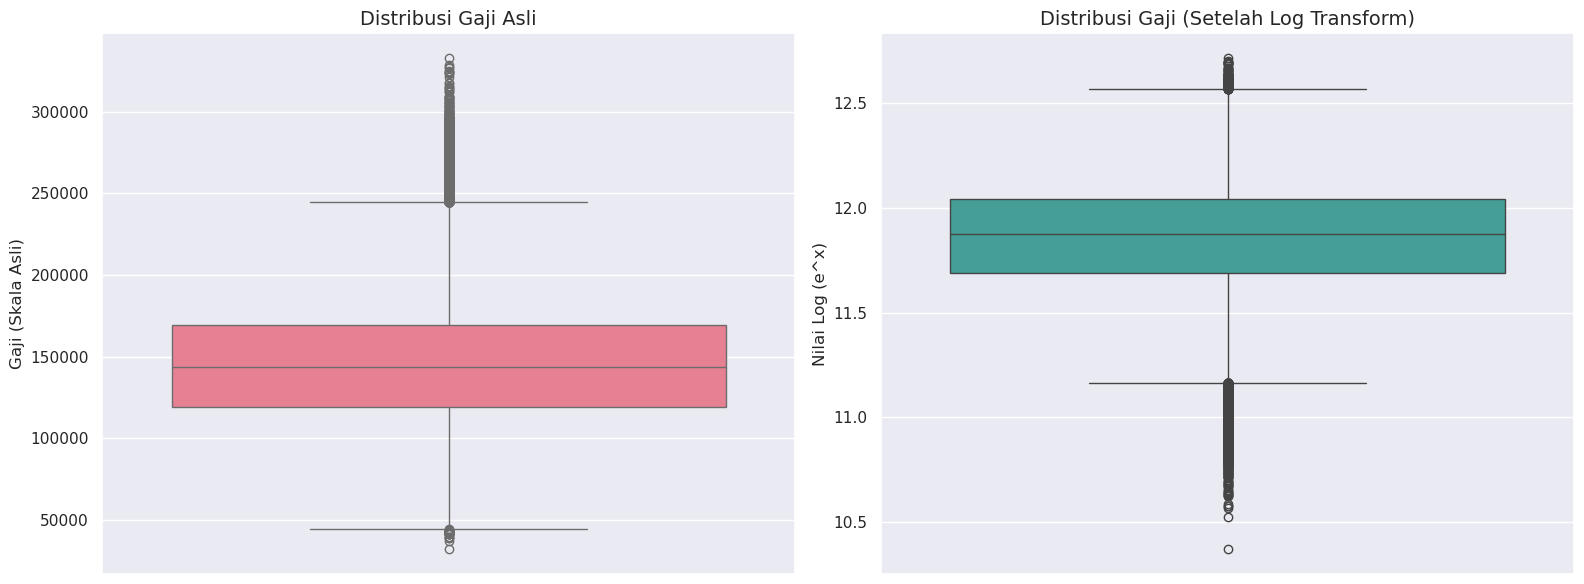

In [16]:
# Menyiapkan tema visual
sns.set_theme(style="darkgrid")
colors = sns.color_palette("husl", 2) # Menggunakan 2 warna yang berbeda

# Membuat figure dengan 2 subplot (1 baris, 2 kolom)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Gaji Asli
sns.boxplot(ax=axes[0], data=df, y='salary', color=colors[0])
axes[0].set_title('Distribusi Gaji Asli', fontsize=14)
axes[0].set_ylabel('Gaji (Skala Asli)', fontsize=12)

# Subplot 2: Gaji Log
# Pastikan Anda menggunakan np.log1p (log(x+1)) untuk keamanan jika ada nilai 0
df['salary_log'] = np.log1p(df['salary']) 
sns.boxplot(ax=axes[1], data=df, y='salary_log', color=colors[1])
axes[1].set_title('Distribusi Gaji (Setelah Log Transform)', fontsize=14)
axes[1].set_ylabel('Nilai Log (e^x)', fontsize=12)

plt.tight_layout() # Mengatur jarak agar rapi
plt.show()

In [17]:
# Cek kolom yang tersedia
print("Kolom dalam dataset:")
print(df.columns.tolist())
print("\nTipe data:")
print(df.dtypes)
print("\nSampel data:")
df.head()

Kolom dalam dataset:
['job_title', 'experience_years', 'education_level', 'skills_count', 'industry', 'company_size', 'location', 'remote_work', 'certifications', 'salary', 'salary_log']

Tipe data:
job_title             int64
experience_years      int64
education_level       int64
skills_count          int64
industry              int64
company_size          int64
location              int64
remote_work           int64
certifications        int64
salary                int64
salary_log          float64
dtype: object

Sampel data:


,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary,salary_log
0,0,10,0,2,4,2,3,0,2,109413,11.602894
1,5,5,0,17,9,3,0,1,0,93764,11.448547
2,8,18,4,4,6,2,6,1,1,148123,11.905805
3,2,19,4,13,7,2,1,2,0,189123,12.150158
4,10,15,0,7,5,1,7,2,0,165069,12.014125


## Feature Engineering

Membuat fitur baru jika diperlukan dan memisahkan fitur dengan target.

In [18]:
# Memisahkan fitur dan target menggunakan target log-transformasi
X = df.drop(['salary', 'salary_log'], axis=1)
y = df['salary_log']

print(f"Jumlah fitur: {X.shape[1]}")
print(f"Jumlah sampel: {X.shape[0]}")

# Split data sebelum normalisasi
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train set: {X_train.shape[0]} sampel")
print(f"Test set: {X_test.shape[0]} sampel")

# Normalisasi fitur numerik dan fitur kategorikal yang sudah di-encode
feature_scaler = StandardScaler()
X_train_scaled = feature_scaler.fit_transform(X_train)
X_test_scaled = feature_scaler.transform(X_test)

print("Fitur telah dinormalisasi.")


Jumlah fitur: 9
Jumlah sampel: 250000
Train set: 200000 sampel
Test set: 50000 sampel
Fitur telah dinormalisasi.


## Simpan Data Processed

In [19]:
import json
from pathlib import Path

# Buat direktori processed jika belum ada
processed_dir = Path('../data/processed')
processed_dir.mkdir(parents=True, exist_ok=True)

# Simpan train-test split data sebagai CSV
import pandas as pd

# Simpan X_train dan X_test (raw features)
pd.DataFrame(X_train).to_csv(processed_dir / 'X_train.csv', index=False)
pd.DataFrame(X_test).to_csv(processed_dir / 'X_test.csv', index=False)

# Simpan y_train dan y_test (log-transformed salary)
y_train.to_csv(processed_dir / 'y_train.csv', index=False)
y_test.to_csv(processed_dir / 'y_test.csv', index=False)

# Simpan scaled data (untuk direct usage)
pd.DataFrame(X_train_scaled, columns=X_train.columns).to_csv(processed_dir / 'X_train_scaled.csv', index=False)
pd.DataFrame(X_test_scaled, columns=X_test.columns).to_csv(processed_dir / 'X_test_scaled.csv', index=False)

# Simpan metadata dalam JSON
metadata = {
    'train_size': len(X_train),
    'test_size': len(X_test),
    'test_size_ratio': 0.2,
    'n_features': X_train.shape[1],
    'feature_names': X_train.columns.tolist(),
    'random_state': 42,
    'preprocessing': {
        'target_transform': 'log1p (salary)',
        'categorical_encoding': 'LabelEncoder',
        'numeric_scaling': 'StandardScaler',
        'scaling_fit_on': 'training_data_only'
    }
}

with open(processed_dir / 'metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print(f'✓ Processed data saved to {processed_dir}/')
print(f'Files created:')
print(f'  - X_train.csv ({len(X_train)} rows)')
print(f'  - X_test.csv ({len(X_test)} rows)')
print(f'  - y_train.csv ({len(y_train)} rows)')
print(f'  - y_test.csv ({len(y_test)} rows)')
print(f'  - X_train_scaled.csv')
print(f'  - X_test_scaled.csv')
print(f'  - metadata.json')


✓ Processed data saved to ../data/processed/
Files created:
  - X_train.csv (200000 rows)
  - X_test.csv (50000 rows)
  - y_train.csv (200000 rows)
  - y_test.csv (50000 rows)
  - X_train_scaled.csv
  - X_test_scaled.csv
  - metadata.json


## Training Model

Membagi data menjadi train dan test, lalu melatih model Random Forest dengan target log-transformasi.

In [33]:
# Melatih model Random Forest dengan data yang sudah dipisah dan dinormalisasi
model = RandomForestRegressor(
    n_estimators=100, 
    max_depth=20,             # Batasi kedalaman maksimum pohon (misal: 20 atau 25)
    min_samples_split=10,       # Minimal 2 sampel di setiap daun terakhir untuk mengurangi over-splitting
    random_state=42,
    n_jobs=-1)
model.fit(X_train_scaled, y_train)

print("Model Random Forest berhasil dilatih!")

Model Random Forest berhasil dilatih!


In [ ]:
import joblib
import json
from pathlib import Path

models_dir = Path('../models')
models_dir.mkdir(parents=True, exist_ok=True)

config_path = Path('../config/config.json')
with open(config_path, 'r', encoding='utf-8') as f:
    config = json.load(f)

model_path = models_dir / config['model']['model_filename']
joblib.dump(model, model_path, compress=3)
print(f'Random Forest model disimpan di: {model_path}')

scaler_path = models_dir / config['model']['scaler_filename']
joblib.dump(feature_scaler, scaler_path)
print(f'Scaler disimpan di: {scaler_path}')

feature_scaler_path = models_dir / config['model']['feature_scaler_filename']
joblib.dump(feature_scaler, feature_scaler_path)
print(f'Feature scaler disimpan di: {feature_scaler_path}')

encoder_path = models_dir / config['model']['encoder_filename']
joblib.dump(encoders, encoder_path)
print(f'Label encoder disimpan di: {encoder_path}')


Random Forest model disimpan di: ../models/random_forest_salary_model.pkl
Scaler disimpan di: ../models/scaler.pkl
Feature scaler disimpan di: ../models/feature_scaler.pkl
Label encoder disimpan di: ../models/label_encoders.pkl


In [35]:
model_path = models_dir / config['model']['model_filename']
joblib.dump(model, model_path, compress=9)
print(f'Random Forest model disimpan di: {model_path}')

Random Forest model disimpan di: ../models/random_forest_salary_model.pkl


## Feature Importance

Melihat fitur mana yang paling berpengaruh terhadap prediksi gaji pada model Random Forest.

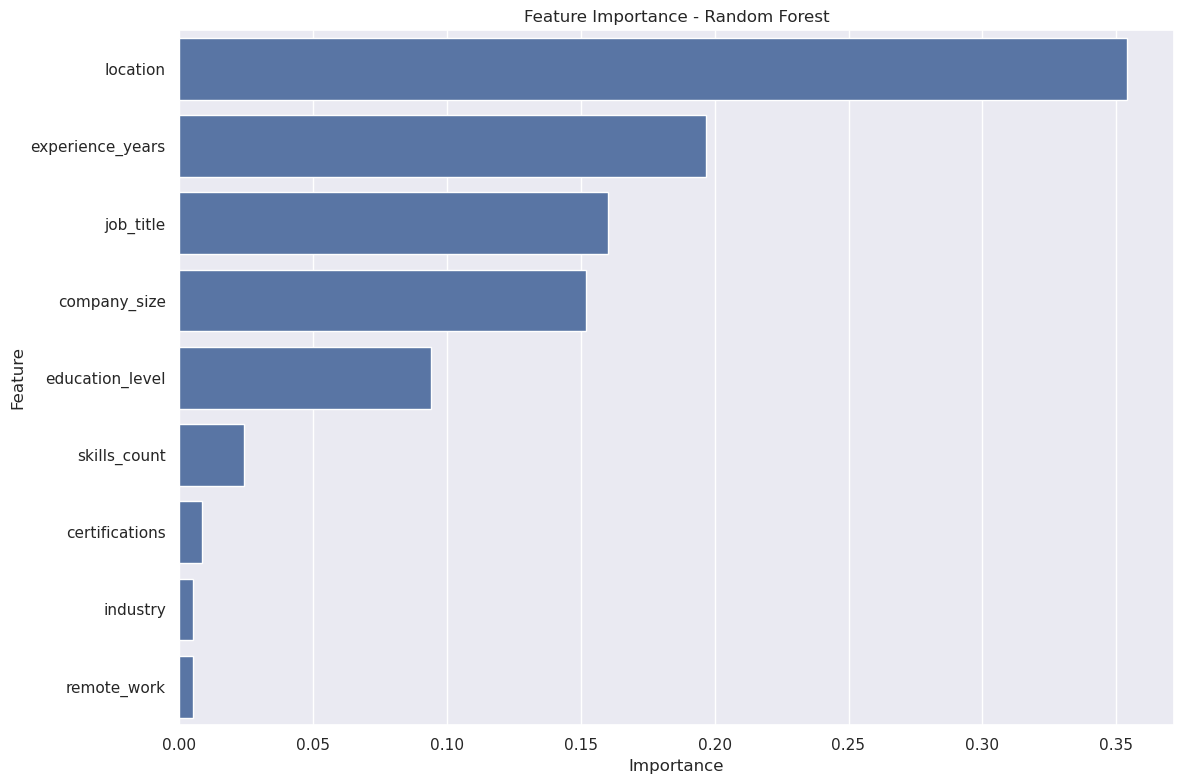

            feature  importance
6          location    0.353850
1  experience_years    0.196783
0         job_title    0.160026
5      company_size    0.151980
2   education_level    0.094056
3      skills_count    0.024113
8    certifications    0.008738
4          industry    0.005340
7       remote_work    0.005114


In [22]:
# Menampilkan feature importance dari model Random Forest
feature_names = X.columns
importances = model.feature_importances_
feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importance_df)
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print(feature_importance_df.head(10))

## Evaluasi Model

Mengevaluasi performa model menggunakan metrik MAE, MSE, MAPE, dan R² pada skala asli setelah back-transformasi.

Mean Absolute Error (MAE): 5355.87
Mean Squared Error (MSE): 45939629.98
Root Mean Squared Error (RMSE): 6777.88
Mean Absolute Percentage Error (MAPE): 3.87%
R² Score: 0.97
Mean Error (ME): 354.17
Median Absolute Error: 4461.73
Std Dev of Errors: 6768.62
Min Error: -38212.23
Max Error: 33319.67


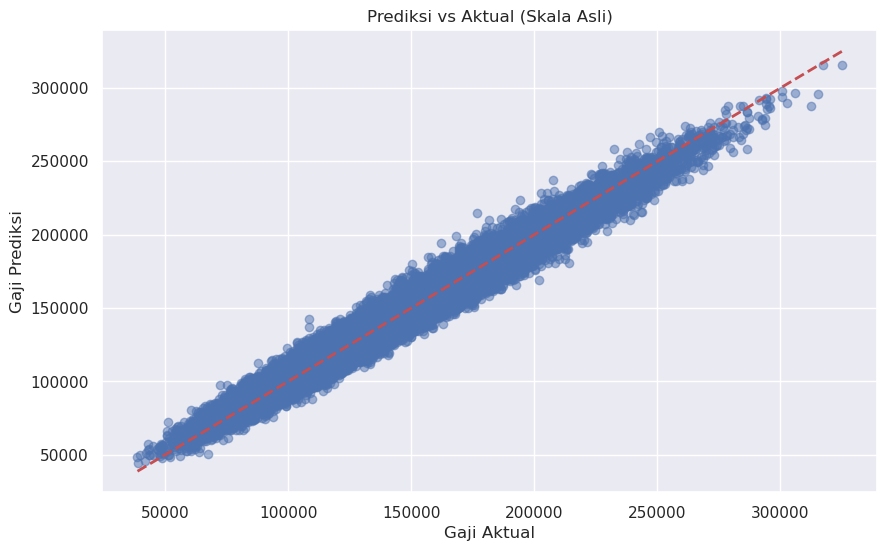

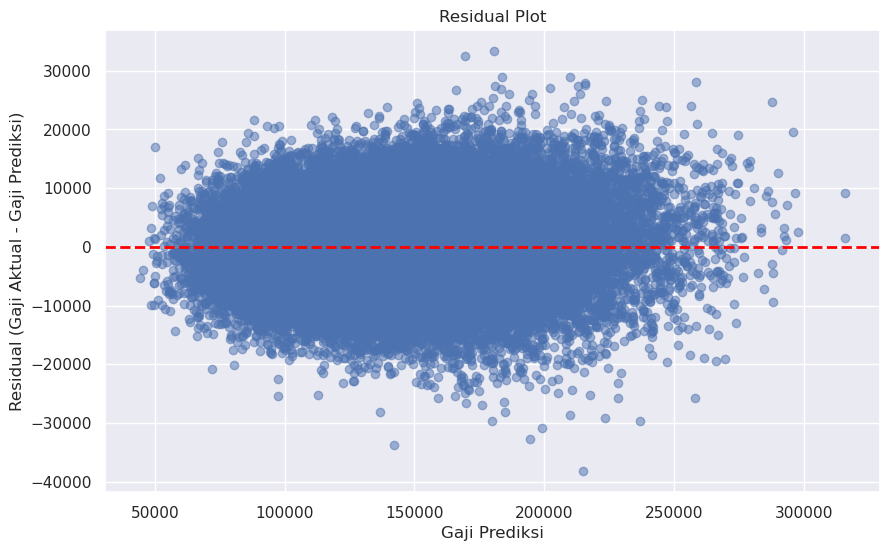

In [34]:
# Prediksi pada test set di skala log
y_pred_log = model.predict(X_test_scaled)

# Back-transformasi ke skala asli
y_pred = np.expm1(y_pred_log)
y_test_orig = np.expm1(y_test)

# Metrik evaluasi pada skala asli
mae = mean_absolute_error(y_test_orig, y_pred)
mse = mean_squared_error(y_test_orig, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_orig, y_pred)
mape = np.mean(np.abs((y_test_orig - y_pred) / y_test_orig)) * 100
error = y_test_orig - y_pred
mean_error = np.mean(error)
median_abs_error = np.median(np.abs(error))
std_error = np.std(error)
min_error = np.min(error)
max_error = np.max(error)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"R² Score: {r2:.2f}")
print(f"Mean Error (ME): {mean_error:.2f}")
print(f"Median Absolute Error: {median_abs_error:.2f}")
print(f"Std Dev of Errors: {std_error:.2f}")
print(f"Min Error: {min_error:.2f}")
print(f"Max Error: {max_error:.2f}")

# Visualisasi prediksi vs aktual pada skala asli
plt.figure(figsize=(10, 6))
plt.scatter(y_test_orig, y_pred, alpha=0.5)
plt.plot([y_test_orig.min(), y_test_orig.max()], [y_test_orig.min(), y_test_orig.max()], 'r--', lw=2)
plt.xlabel('Gaji Aktual')
plt.ylabel('Gaji Prediksi')
plt.title('Prediksi vs Aktual (Skala Asli)')
plt.show()

# Residual plot untuk memeriksa pola residual
residuals = y_test_orig - y_pred
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Gaji Prediksi')
plt.ylabel('Residual (Gaji Aktual - Gaji Prediksi)')
plt.title('Residual Plot')
plt.show()

## Kesimpulan

Model Random Forest telah dilatih dan dievaluasi dengan target log-transformasi. Anda dapat meningkatkan performa lebih lanjut dengan testing parameter model, fitur tambahan, atau algoritma lainnya.

Simpan model jika diperlukan:
```python
import joblib
joblib.dump(model, '../models/salary_model.pkl')
```